In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


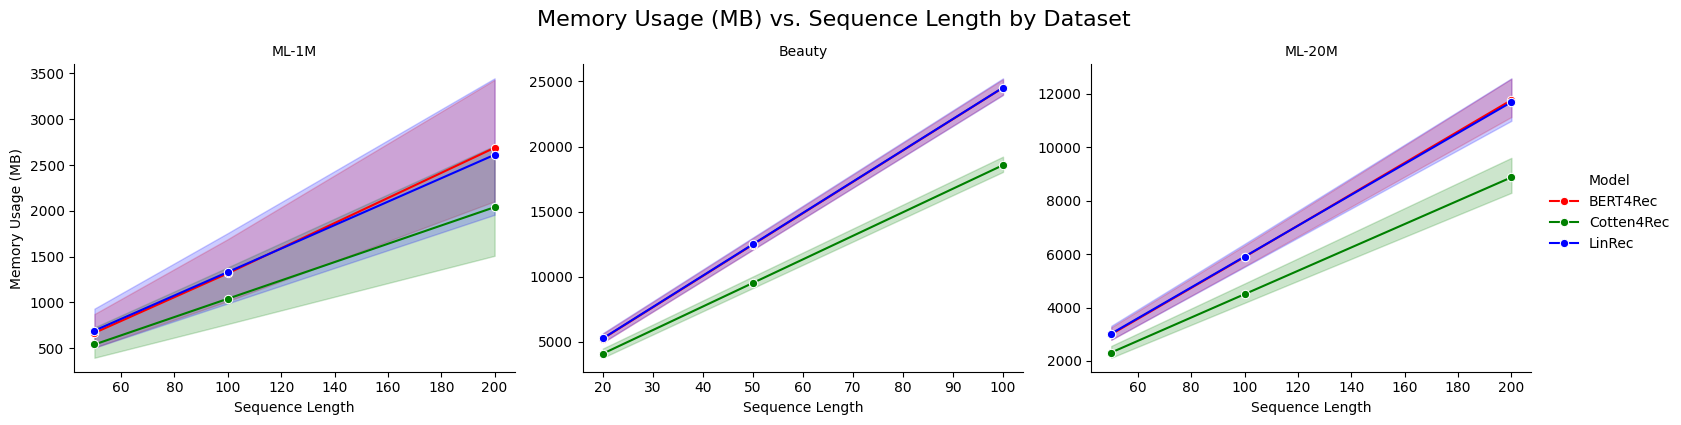

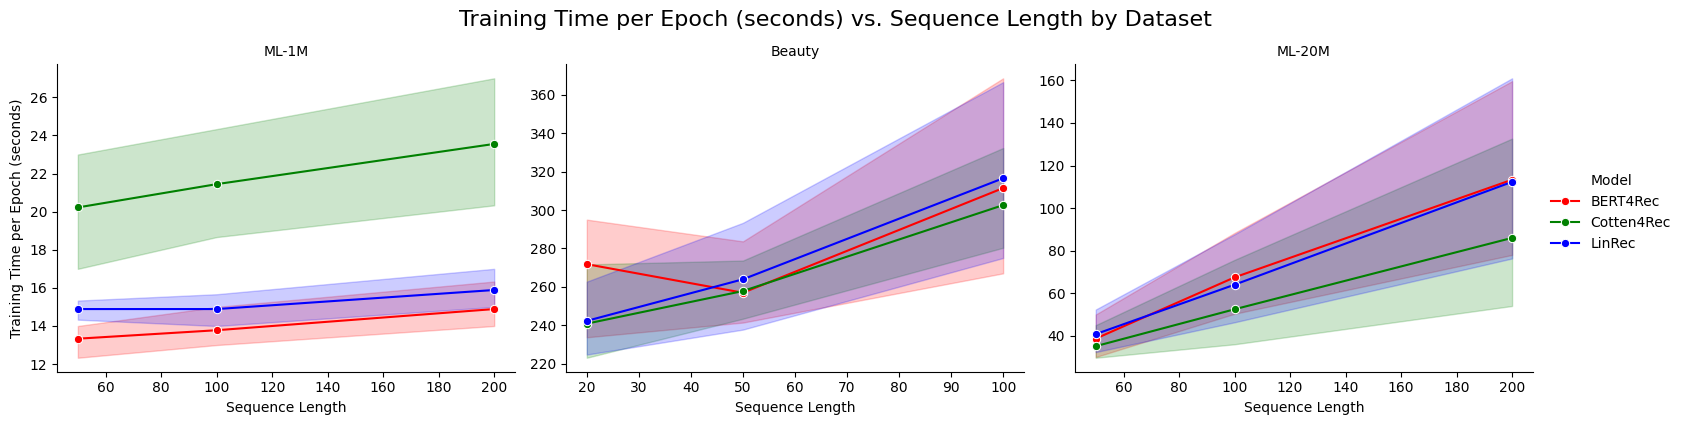

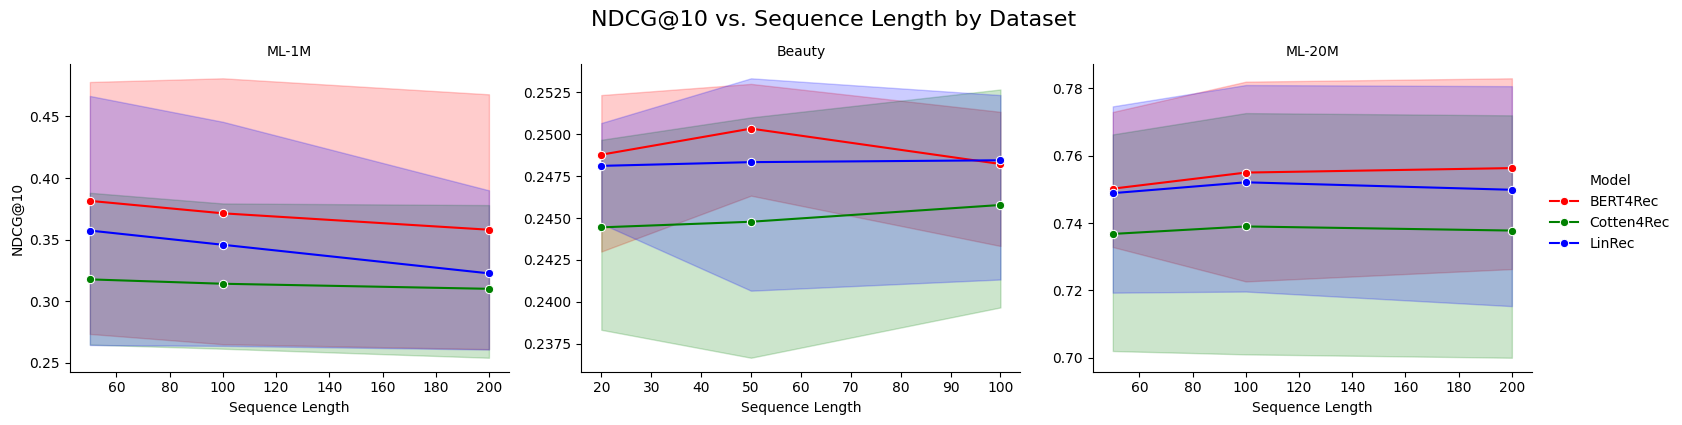

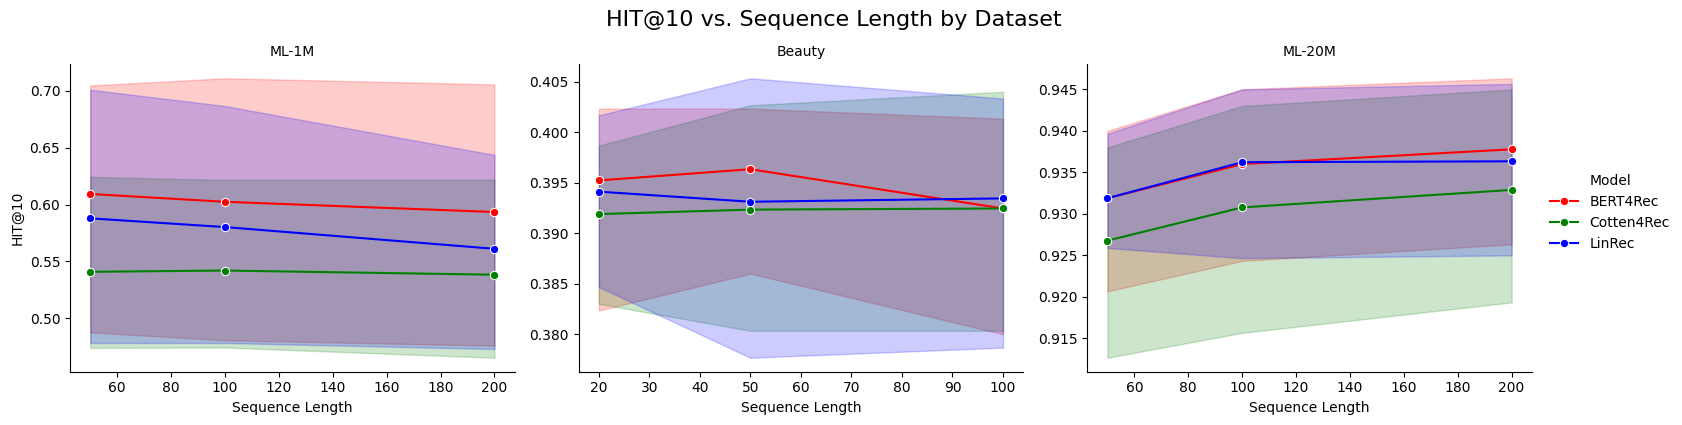

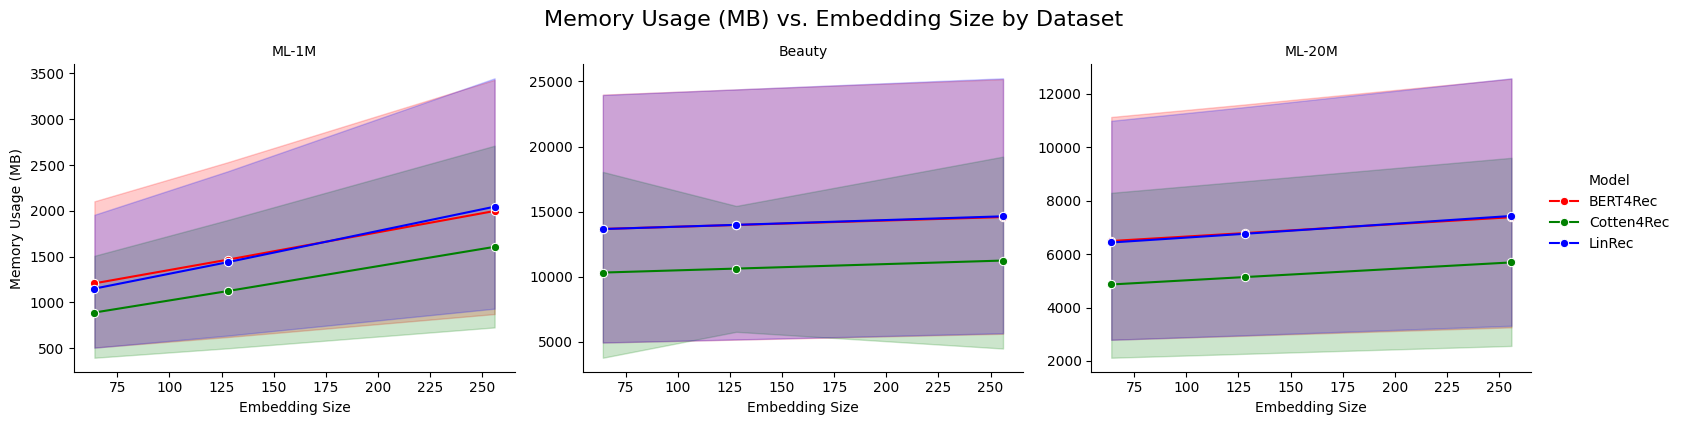

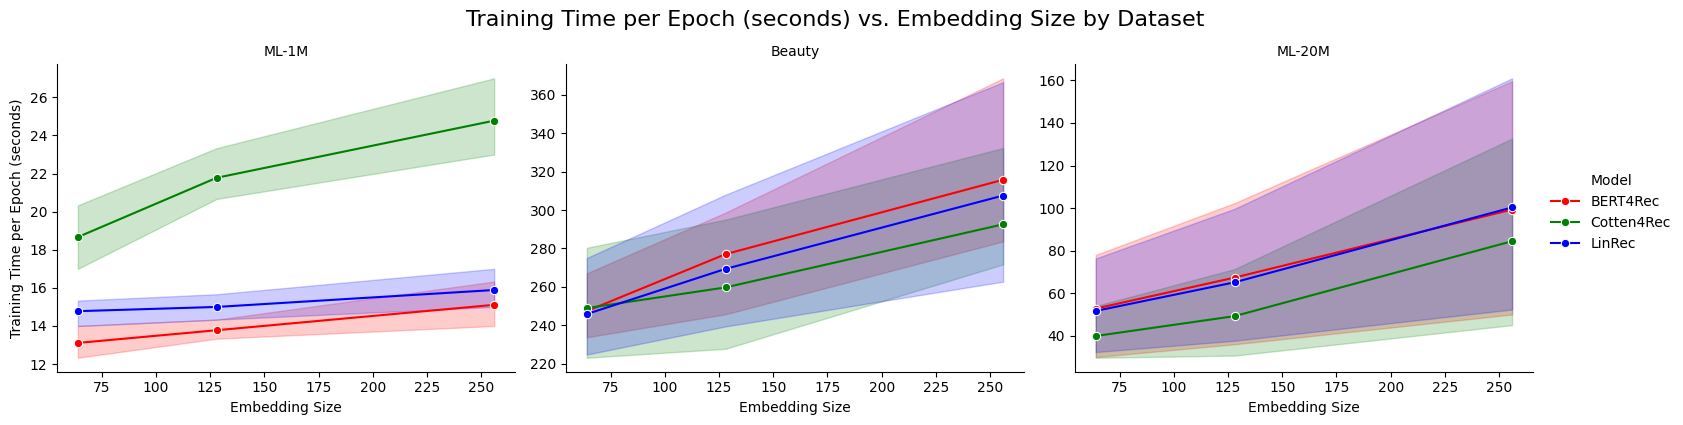

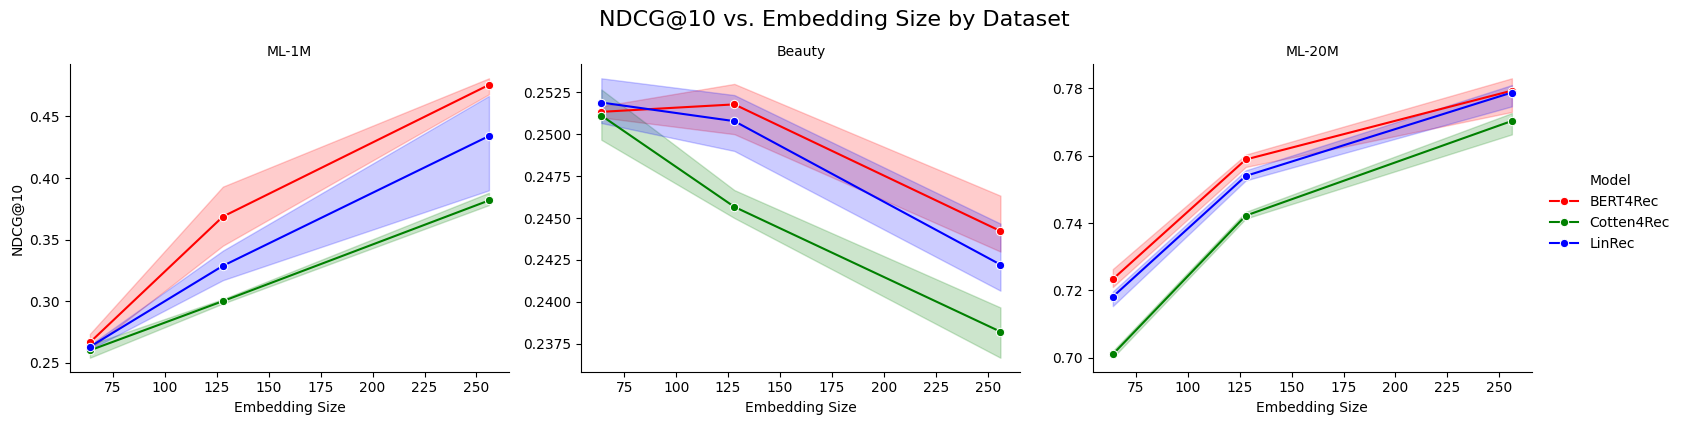

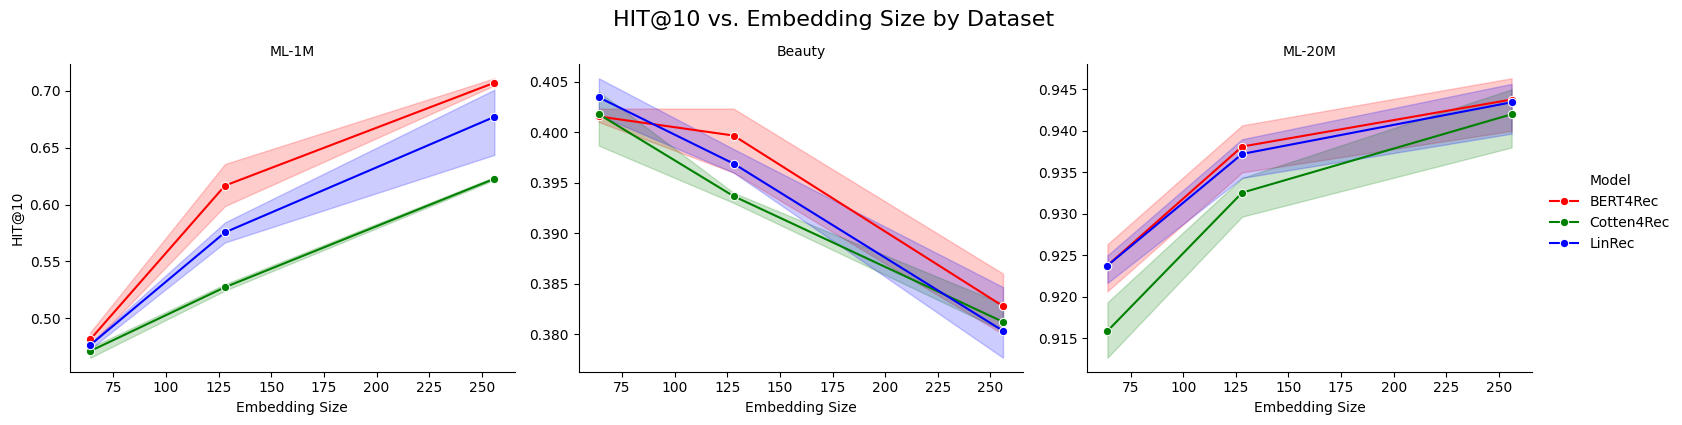

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def facet_plot_by_dataset(df, x_col, y_col):
    """
    Create a FacetGrid where:
      - columns represent different datasets
      - hue is the model (BERT4Rec, Cotten4Rec, LinRec)
      - x_col is the x-axis (sequence length or embedding size)
      - y_col is the chosen metric (memory usage, training time, NDCG@10, HIT@10)
    """
    models_to_plot = ["BERT4Rec", "Cotten4Rec", "LinRec"]
    df = df[df['Model'].isin(models_to_plot)]

    df = df.sort_values(by=x_col) # Sort for a smoother line plot

    # Define a fixed order for the models (hue) and the dataset (columns)
    hue_order = ["BERT4Rec", "Cotten4Rec", "LinRec"]
    palette = {
        "BERT4Rec": "red",
        "Cotten4Rec": "green",
        "LinRec": "blue"
    }

    col_order = ["ML-1M", "Beauty", "ML-20M"]

    g = sns.FacetGrid(
        df,
        col="Dataset",
        col_order=col_order,
        hue="Model",
        hue_order=hue_order,
        palette=palette,
        sharey=False,
        sharex=False,
        height=4,
        aspect=1.3
    )

    # Map Seaborn's lineplot onto the FacetGrid
    g.map(sns.lineplot, x_col, y_col, marker="o").add_legend()

    # Label axes
    g.set_axis_labels(x_col, y_col)
    # Set subplot titles to the dataset name
    g.set_titles(col_template="{col_name}")

    # Global title
    plt.suptitle(f"{y_col} vs. {x_col} by Dataset", y=1.05, fontsize=16)
    plt.show()


if __name__ == "__main__":
    df = pd.read_csv("/content/drive/MyDrive/BERT4Rec_Data/Experimental_Results.csv")

    # List all the index columns except seeds
    group_cols = ["Dataset", "Model", "Sequence Length", "Embedding Size"]

    # List all metrics to be averaged
    metric_cols = ["Memory Usage (MB)", "Training Time per Epoch (seconds)", "NDCG@10", "HIT@10"]

    # Compute the mean over seeds
    df = (
        df.groupby(group_cols, as_index=False)[metric_cols].mean()
    )

    # Plots with x-axis = "sequence length"
    for metric in ["Memory Usage (MB)", "Training Time per Epoch (seconds)", "NDCG@10", "HIT@10"]:
        facet_plot_by_dataset(df, x_col="Sequence Length", y_col=metric)

    # Plots with x-axis = "embedding size"
    for metric in ["Memory Usage (MB)", "Training Time per Epoch (seconds)", "NDCG@10", "HIT@10"]:
        facet_plot_by_dataset(df, x_col="Embedding Size", y_col=metric)


In [3]:
import pandas as pd

# Load experimental results CSV
df = pd.read_csv("/content/drive/MyDrive/BERT4Rec_Data/Experimental_Results.csv")

# Compute per-(Dataset,Seed,Model) averages
metrics = ["Memory Usage (MB)", "Training Time (seconds)", "NDCG@10", "HIT@10"]
agg = (
    df
    .groupby(["Dataset","Seed","Model"], as_index=False)[metrics]
    .mean()
)

# Pivot so each model is a column
pivot = agg.pivot_table(
    index=["Dataset","Seed"],
    columns="Model",
    values=metrics
)
# Flatten multiindex columns
pivot.columns = ["_".join(col).strip() for col in pivot.columns.values]
pivot = pivot.reset_index()

# Helper to compute percent difference new vs baseline
def pct_diff(new, base):
    return (new - base) / base * 100

# For each row, compute the six comparisons
out = []
for _, row in pivot.iterrows():
    ds = row["Dataset"]
    seed = row["Seed"]
    B = row["Memory Usage (MB)_BERT4Rec"]
    C = row["Memory Usage (MB)_Cotten4Rec"]
    L = row["Memory Usage (MB)_LinRec"]

    entry = {
        "Dataset": ds,
        # Cotten vs BERT
        "Mem↓_C_vs_B (%)":    pct_diff(C, B),
        "Time↑_C_vs_B (%)":   pct_diff(
            -row["Training Time (seconds)_Cotten4Rec"],
            -row["Training Time (seconds)_BERT4Rec"]
        ),
        "NDCG↓_C_vs_B (%)":   pct_diff(row["NDCG@10_Cotten4Rec"],    row["NDCG@10_BERT4Rec"]),
        "HIT↓_C_vs_B (%)":    pct_diff(row["HIT@10_Cotten4Rec"],     row["HIT@10_BERT4Rec"]),
        # Cotten vs LinRec
        "Mem↓_C_vs_L (%)":    pct_diff(C, L),
        "Time↑_C_vs_L (%)":   pct_diff(
            -row["Training Time (seconds)_Cotten4Rec"],
            -row["Training Time (seconds)_LinRec"]
        ),
        "NDCG↓_C_vs_L (%)":   pct_diff(row["NDCG@10_Cotten4Rec"],    row["NDCG@10_LinRec"]),
        "HIT↓_C_vs_L (%)":    pct_diff(row["HIT@10_Cotten4Rec"],     row["HIT@10_LinRec"]),
    }
    out.append(entry)

results_df = pd.DataFrame(out)

# Average across seeds for each dataset
summary = (
    results_df
    .groupby("Dataset", as_index=False)
    .mean()
    .round(1)
)

print(summary.to_string(index=False))

Dataset  Mem↓_C_vs_B (%)  Time↑_C_vs_B (%)  NDCG↓_C_vs_B (%)  HIT↓_C_vs_B (%)  Mem↓_C_vs_L (%)  Time↑_C_vs_L (%)  NDCG↓_C_vs_L (%)  HIT↓_C_vs_L (%)
 Beauty            -23.8              -4.3              -1.6             -0.6            -23.9              -2.5              -1.3             -0.3
  ML-1M            -22.5              55.6             -15.2            -10.2            -21.9              43.3              -8.2             -6.2
 ML-20M            -24.0             -20.9              -2.1             -0.5            -23.9             -20.0              -1.7             -0.5
